# MATH GR5360 Final Project — Notebook 02

Segmented trend-following strategy notebook. This notebook imports the shared engine, runs one TF sanity check for `Channel WithDDControl`, and then performs the TF walk-forward optimization used in the project-facing workflow.


In [1]:
MARKET_SELECT = 'TY'
QUICK_TEST = True
WALKFORWARD_MODE = 'tf'
RUN_EXTENDED_SURFACE = False

DATA_INTERVAL_MINUTES = 1
DATA_FILE_OVERRIDE = None  # use repo data folder
RESULTS_CACHE_DIR = r'/Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/results_py_corrected'
# Note: the repo currently contains TY-1minHLV.csv but no valid BTC-1minHLV.csv.


In [2]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD if (CWD / 'mafn_engine').exists() else CWD.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from mafn_engine import (
    COLUMBIA_CORE,
    COLUMBIA_NAVY,
    COLUMBIA_RED,
    apply_columbia_theme,
    choose_tf_story_configuration,
    default_tf_grid,
    get_market,
    load_ohlc,
    prepare_analysis_frame,
    run_tf_backtest,
    walk_forward,
)

apply_columbia_theme()
MARKET = get_market(MARKET_SELECT)
DATA_PATH = DATA_FILE_OVERRIDE or str(PROJECT_ROOT / 'data')
print(f"Market: {MARKET.ticker} - {MARKET.name} ({MARKET.exchange})")
print(f"PV=${MARKET.PV:,}  Slippage=${MARKET.slpg}  E0=${MARKET.E0:,.0f}")


Market: TY - 10-Year Treasury (CBOT-CME)
PV=$1,000  Slippage=$18.625  E0=$100,000


In [3]:
def _grid_signature(grid: dict[str, np.ndarray]) -> tuple[tuple[str, tuple[float, ...]], ...]:
    signature = []
    for key in sorted(grid):
        values = []
        for value in np.asarray(grid[key]).tolist():
            if isinstance(value, (int, np.integer)):
                values.append(int(value))
            else:
                values.append(float(value))
        signature.append((key, tuple(values)))
    return tuple(signature)


def _market_cache_dir() -> Path | None:
    if not RESULTS_CACHE_DIR:
        return None
    return Path(RESULTS_CACHE_DIR) / f"{MARKET_SELECT}_{int(DATA_INTERVAL_MINUTES)}m"


def _read_ledger_csv(path: Path) -> pd.DataFrame:
    ledger = pd.read_csv(path)
    for column in ['entry_time', 'exit_time']:
        if column in ledger.columns:
            ledger[column] = pd.to_datetime(ledger[column])
    return ledger


def ensure_analysis_state(force: bool = False) -> None:
    global MARKET, full_df, analysis_df, tf_grid, _analysis_signature

    MARKET = get_market(MARKET_SELECT)
    analysis_signature = (MARKET_SELECT, DATA_PATH, int(DATA_INTERVAL_MINUTES))
    if force or globals().get('_analysis_signature') != analysis_signature or 'analysis_df' not in globals():
        full_df = load_ohlc(DATA_PATH, MARKET_SELECT, fallback_synthetic=False, bar_minutes=DATA_INTERVAL_MINUTES)
        analysis_df = prepare_analysis_frame(full_df, MARKET_SELECT)
        _analysis_signature = analysis_signature

    tf_grid = default_tf_grid(MARKET_SELECT, quick=QUICK_TEST, bar_minutes=DATA_INTERVAL_MINUTES)


def ensure_walkforward_state(force: bool = False) -> None:
    global wf_bundle, wf_params, wf_equity, wf_ledger, wf_results, _wf_signature

    ensure_analysis_state(force=force)
    signature = (
        MARKET_SELECT,
        DATA_PATH,
        int(DATA_INTERVAL_MINUTES),
        WALKFORWARD_MODE,
        bool(QUICK_TEST),
        4,
        1,
        _grid_signature(tf_grid),
        str(_market_cache_dir()) if _market_cache_dir() else '',
    )

    if force or globals().get('_wf_signature') != signature or 'wf_bundle' not in globals():
        cache_dir = _market_cache_dir()
        params_path = cache_dir / f"{MARKET_SELECT}_{int(DATA_INTERVAL_MINUTES)}m_walkforward_params.csv" if cache_dir else None
        equity_path = cache_dir / f"{MARKET_SELECT}_{int(DATA_INTERVAL_MINUTES)}m_walkforward_equity.csv" if cache_dir else None
        ledger_path = cache_dir / f"{MARKET_SELECT}_{int(DATA_INTERVAL_MINUTES)}m_walkforward_ledger.csv" if cache_dir else None

        if cache_dir and params_path.exists() and equity_path.exists() and ledger_path.exists():
            wf_params = pd.read_csv(params_path)
            wf_equity = pd.read_csv(equity_path, parse_dates=['DateTime']).set_index('DateTime')
            wf_ledger = _read_ledger_csv(ledger_path)
            wf_bundle = {'params': wf_params, 'equity': wf_equity, 'ledger': wf_ledger}
        else:
            wf_bundle = walk_forward(
                analysis_df,
                MARKET_SELECT,
                mode=WALKFORWARD_MODE,
                tf_grid=tf_grid,
                T_years=4,
                tau_quarters=1,
                quick=QUICK_TEST,
                verbose=True,
            )
            wf_params = wf_bundle['params']
            wf_equity = wf_bundle['equity']
            wf_ledger = wf_bundle['ledger']

        _wf_signature = signature

    wf_params = wf_bundle['params']
    wf_equity = wf_bundle['equity']
    wf_ledger = wf_bundle['ledger']
    wf_results = wf_params


ensure_analysis_state(force=True)

tf_combos = len(tf_grid['L']) * len(tf_grid['S'])
print(f"TF grid combinations: {tf_combos:,}")
print('Project-facing workflow: trend-following only.')
if RESULTS_CACHE_DIR:
    print(f"Using cached walk-forward artifacts from {RESULTS_CACHE_DIR}")


✓ Loaded TY from /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/data/TY-1minHLV.csv


TF grid combinations: 35
Project-facing workflow: trend-following only.
Using cached walk-forward artifacts from /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/results_py_corrected


In [4]:
ensure_analysis_state()

story_cfg = choose_tf_story_configuration(MARKET_SELECT, tf_grid=tf_grid, params_df=pd.DataFrame())
tf_sanity = run_tf_backtest(analysis_df, MARKET_SELECT, L=int(story_cfg['L']), S=float(story_cfg['S']))

sanity_summary_df = pd.DataFrame([
    {
        'Family': 'tf',
        'L': int(story_cfg['L']),
        'S': float(story_cfg['S']),
        'Profit': tf_sanity['Profit'],
        'MaxDD': tf_sanity['MaxDD'],
        'Objective': tf_sanity['Objective'],
        'Trades': tf_sanity['NumTrades'],
    },
])
sanity_summary_df


,Family,L,S,Profit,MaxDD,Objective,Trades
0,tf,4800,0.02,58694.875,42770.125,1.372333,611


In [5]:
ensure_walkforward_state(force=True)

print()
print('TF WALK-FORWARD COMPLETE')
print('-' * 72)
print(f"Periods: {len(wf_params)}")
print(f"Ledger rows: {len(wf_ledger)}")
wf_params.head()


✓ Loaded TY from /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/data/TY-1minHLV.csv



TF WALK-FORWARD COMPLETE
------------------------------------------------------------------------
Periods: 155
Ledger rows: 401


,Period,Family,IS_start,IS_end,OOS_start,OOS_end,L,S,IS_Objective,IS_Profit,IS_MaxDD,OOS_Objective,OOS_Profit,OOS_MaxDD,OOS_Trades,RoundTurnCost
0,1,tf,1983-01-03 08:01:00,1987-06-05 14:00:00,1987-06-08 08:01:00,1987-09-15 14:00:00,4800,0.02,4.993551,26231.1250,5253.0,0.646443,2052.3750,3174.875,4,18.625
1,2,tf,1983-04-13 08:01:00,1987-09-15 14:00:00,1987-09-16 08:01:00,1987-12-23 14:00:00,4800,0.02,5.078883,26679.3750,5253.0,2.053785,6603.6875,3215.375,4,18.625
2,3,tf,1983-07-22 08:01:00,1987-12-23 14:00:00,1987-12-24 08:01:00,1988-04-05 14:00:00,4800,0.02,5.749964,30204.5625,5253.0,0.317746,1259.1875,3962.875,3,18.625
3,4,tf,1983-10-31 08:01:00,1988-04-05 14:00:00,1988-04-06 08:01:00,1988-07-14 14:00:00,4800,0.02,6.213247,32638.1875,5253.0,0.846462,1806.5625,2134.250,2,18.625
4,5,tf,1984-02-09 08:01:00,1988-07-14 14:00:00,1988-07-15 08:01:00,1988-10-21 14:00:00,4800,0.02,6.590960,34622.3125,5253.0,-0.464046,-1539.9375,3318.500,5,18.625


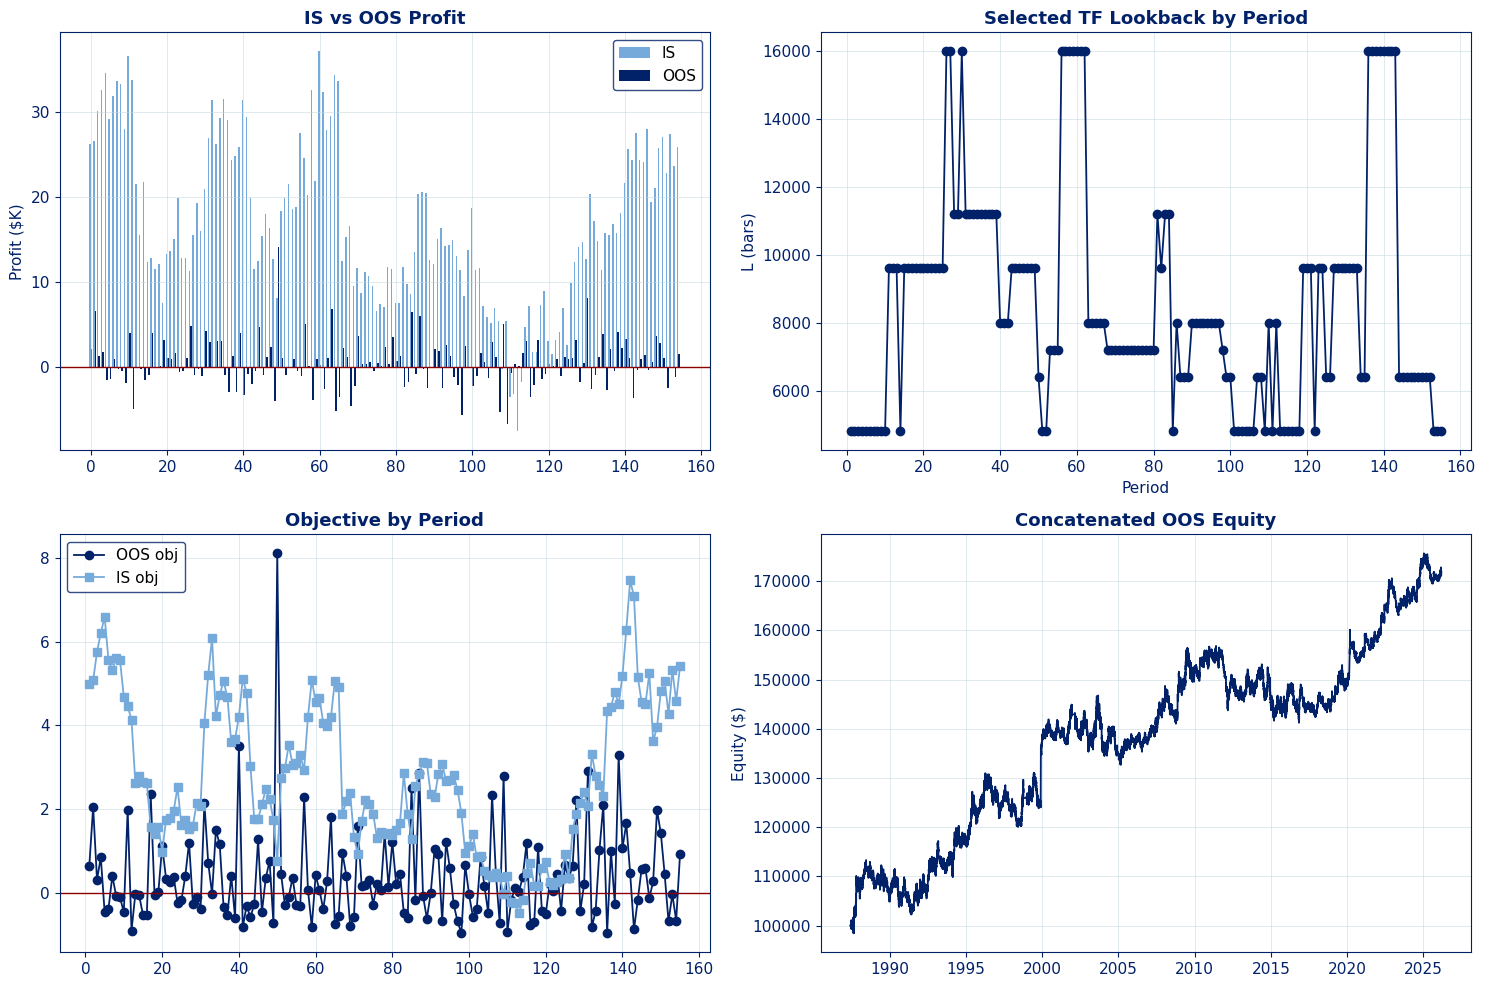

,Period,Family,IS_start,IS_end,OOS_start,OOS_end,L,S,IS_Objective,IS_Profit,IS_MaxDD,OOS_Objective,OOS_Profit,OOS_MaxDD,OOS_Trades,RoundTurnCost
0,1,tf,1983-01-03 08:01:00,1987-06-05 14:00:00,1987-06-08 08:01:00,1987-09-15 14:00:00,4800,0.02,4.993551,26231.12500,5253.00000,0.646443,2052.37500,3174.87500,4,18.625
1,2,tf,1983-04-13 08:01:00,1987-09-15 14:00:00,1987-09-16 08:01:00,1987-12-23 14:00:00,4800,0.02,5.078883,26679.37500,5253.00000,2.053785,6603.68750,3215.37500,4,18.625
2,3,tf,1983-07-22 08:01:00,1987-12-23 14:00:00,1987-12-24 08:01:00,1988-04-05 14:00:00,4800,0.02,5.749964,30204.56250,5253.00000,0.317746,1259.18750,3962.87500,3,18.625
3,4,tf,1983-10-31 08:01:00,1988-04-05 14:00:00,1988-04-06 08:01:00,1988-07-14 14:00:00,4800,0.02,6.213247,32638.18750,5253.00000,0.846462,1806.56250,2134.25000,2,18.625
4,5,tf,1984-02-09 08:01:00,1988-07-14 14:00:00,1988-07-15 08:01:00,1988-10-21 14:00:00,4800,0.02,6.590960,34622.31250,5253.00000,-0.464046,-1539.93750,3318.50000,5,18.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,151,tf,2020-12-31 12:51:00,2024-12-09 08:00:00,2024-12-09 08:01:00,2025-03-11 08:50:00,6400,0.01,5.066568,27090.62500,5346.93750,0.443019,1005.03125,2268.59375,4,18.625
151,152,tf,2021-04-01 10:11:00,2025-03-11 08:50:00,2025-03-11 08:51:00,2025-06-09 10:50:00,6400,0.01,4.269325,22827.81250,5346.93750,-0.678653,-2547.87500,3754.31250,7,18.625
152,153,tf,2021-06-30 09:16:00,2025-06-09 10:50:00,2025-06-09 10:51:00,2025-09-05 10:10:00,4800,0.01,5.322254,27476.96875,5162.65625,-0.035039,-76.59375,2185.96875,3,18.625
153,154,tf,2021-09-27 13:16:00,2025-09-05 10:10:00,2025-09-05 10:11:00,2025-12-03 13:55:00,4800,0.01,4.580660,23648.37500,5162.65625,-0.659335,-1191.62500,1807.31250,4,18.625


In [6]:
ensure_walkforward_state()

if len(wf_params):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    x = np.arange(len(wf_params))

    has_is_profit = 'IS_Profit' in wf_params.columns
    has_oos_profit = 'OOS_Profit' in wf_params.columns
    if has_is_profit and has_oos_profit:
        axes[0, 0].bar(x - 0.2, wf_params['IS_Profit'] / 1000, width=0.4, color=COLUMBIA_CORE, label='IS')
        axes[0, 0].bar(x + 0.2, wf_params['OOS_Profit'] / 1000, width=0.4, color=COLUMBIA_NAVY, label='OOS')
        axes[0, 0].legend()
    elif has_oos_profit:
        axes[0, 0].bar(x, wf_params['OOS_Profit'] / 1000, width=0.6, color=COLUMBIA_NAVY, label='OOS')
        axes[0, 0].legend()
    else:
        axes[0, 0].text(0.5, 0.5, 'No profit history generated', ha='center', va='center')
    axes[0, 0].axhline(0.0, color=COLUMBIA_RED, linewidth=1)
    axes[0, 0].set_title('IS vs OOS Profit')
    axes[0, 0].set_ylabel('Profit ($K)')

    if 'L' in wf_params:
        axes[0, 1].plot(wf_params['Period'], wf_params['L'], marker='o', color=COLUMBIA_NAVY)
        axes[0, 1].set_title('Selected TF Lookback by Period')
        axes[0, 1].set_ylabel('L (bars)')
        axes[0, 1].set_xlabel('Period')
    else:
        axes[0, 1].text(0.5, 0.5, 'No TF parameter history generated', ha='center', va='center')
        axes[0, 1].set_axis_off()

    has_is_obj = 'IS_Objective' in wf_params.columns
    has_oos_obj = 'OOS_Objective' in wf_params.columns
    if has_oos_obj:
        axes[1, 0].plot(wf_params['Period'], wf_params['OOS_Objective'], marker='o', color=COLUMBIA_NAVY, label='OOS obj')
    if has_is_obj:
        axes[1, 0].plot(wf_params['Period'], wf_params['IS_Objective'], marker='s', color=COLUMBIA_CORE, label='IS obj')
    axes[1, 0].axhline(0.0, color=COLUMBIA_RED, linewidth=1)
    axes[1, 0].set_title('Objective by Period')
    if has_is_obj or has_oos_obj:
        axes[1, 0].legend(loc='best')

    if len(wf_equity):
        axes[1, 1].plot(wf_equity.index, wf_equity['OOS_Equity'], color=COLUMBIA_NAVY)
        axes[1, 1].set_title('Concatenated OOS Equity')
        axes[1, 1].set_ylabel('Equity ($)')
    else:
        axes[1, 1].text(0.5, 0.5, 'No OOS equity generated', ha='center', va='center')
        axes[1, 1].set_axis_off()

    plt.tight_layout()
    plt.show()

wf_params


In [7]:
ensure_walkforward_state()

if len(wf_ledger):
    print()
    print('OOS TRADE LEDGER PREVIEW')
    print('-' * 72)
    wf_ledger.head(20)
else:
    print('No OOS trades generated.')



OOS TRADE LEDGER PREVIEW
------------------------------------------------------------------------
